In [3]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/rasymo_sesija.csv")

In [4]:
from sklearn.cluster import KMeans

user_features = df.groupby("vartotojo_id").agg({
    "wpm": "mean",
    "tikslumas": "mean",
    "klaidos": "mean",
    "sesijos_id": "count"
}).reset_index()

user_features.head()

,vartotojo_id,wpm,tikslumas,klaidos,sesijos_id
0,1,59.320667,86.404667,3.366667,30
1,2,69.260333,84.089333,3.766667,30
2,3,46.160000,88.422000,2.866667,30
3,4,64.648667,84.922667,3.333333,30
4,5,42.809667,89.476333,2.800000,30


In [5]:
X = user_features[["wpm", "tikslumas", "klaidos"]]

kmeans = KMeans(n_clusters=3, random_state=42)
user_features["cluster"] = kmeans.fit_predict(X)

user_features.head()

,vartotojo_id,wpm,tikslumas,klaidos,sesijos_id,cluster
0,1,59.320667,86.404667,3.366667,30,1
1,2,69.260333,84.089333,3.766667,30,1
2,3,46.160000,88.422000,2.866667,30,2
3,4,64.648667,84.922667,3.333333,30,1
4,5,42.809667,89.476333,2.800000,30,2


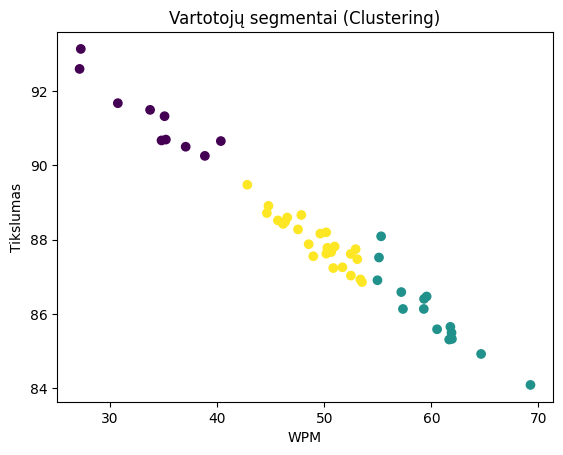

In [6]:
plt.figure()

plt.scatter(
    user_features["wpm"],
    user_features["tikslumas"],
    c=user_features["cluster"]
)

plt.title("Vartotojų segmentai (Clustering)")
plt.xlabel("WPM")
plt.ylabel("Tikslumas")
plt.show()